# Using K-Means Clustering to determine the categories of Countries depending on living conditions

## Exploratory Data Analysis (EDA)

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.offline as pyo
import plotly.graph_objs as go
import plotly.express as px
import numpy as np

In [4]:
df = pd.read_csv(r'C:\Users\HP\KaggleDatasets\Country-data.csv')

In [5]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [6]:
duplicates = df[df.duplicated(subset=['country'], keep = False )]
print(duplicates)

Empty DataFrame
Columns: [country, child_mort, exports, health, imports, income, inflation, life_expec, total_fer, gdpp]
Index: []


In [7]:
missing_columns = df.columns[df.isnull().any()]
print(missing_columns)

Index([], dtype='object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


### Detecting Outliers using Z-Score

In [10]:
def detect_outliers(data):
    outliers = []  # Move the outliers list inside the function to avoid reuse issues
    threshold = 3  # Z-score threshold
    mean = np.mean(data)
    std = np.std(data)
    
    for i in data:
        z_score = (i - mean) / std 
        if np.abs(z_score) > threshold:
            outliers.append(i)  # Append the current data point (i) instead of y
    return outliers

In [11]:
for col in df.drop(columns=['country']).columns:
    outliers = detect_outliers(df[col])     
    print(f"{col} = {outliers}")

child_mort = [208.0, 160.0]
exports = [175.0, 153.0, 200.0]
health = [17.9]
imports = [142.0, 154.0, 174.0]
income = [80600, 75200, 91700, 125000]
inflation = [104.0, 45.9]
life_expec = [32.1]
total_fer = [7.49]
gdpp = [105000, 87800, 70300, 74600]


In [12]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


### Data Visualization

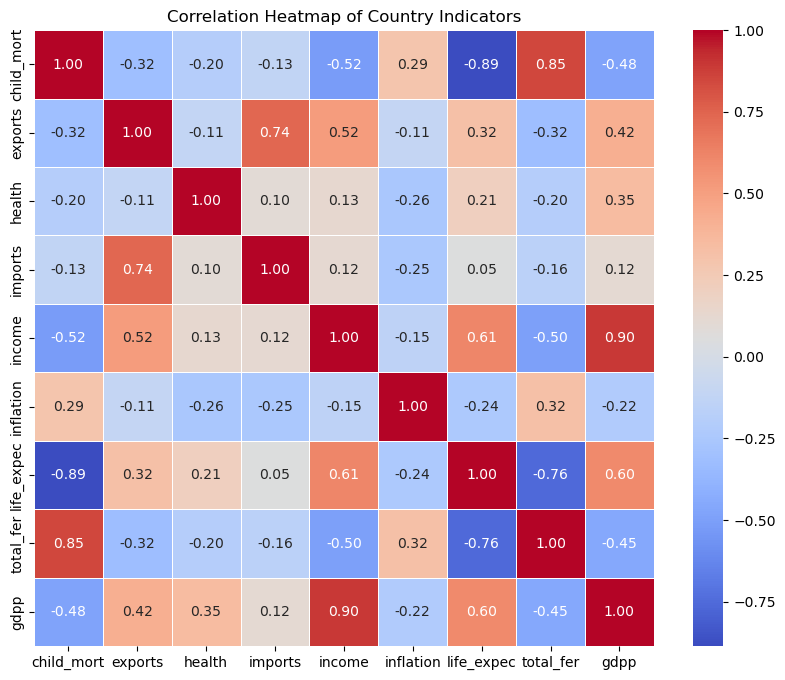

In [14]:
df_numeric = df.select_dtypes(include=['number'])  
corr_matrix = df_numeric.corr()  

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, linewidths=0.5)

# Title and labels
plt.title('Correlation Heatmap of Country Indicators')
plt.show()

## Pre-Processing

### Standard Scaler

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [19]:
X = df[["child_mort", "exports", "health", "income", "inflation", "life_expec", "total_fer", "gdpp"]]

In [20]:
scaler = StandardScaler()

In [21]:
X_scaled = scaler.fit_transform(X)

In [22]:
X_scaled

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]])

## Modelling

### Making an overall score

In [25]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [26]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [27]:
def child_mort_score(value):
    if value <= 8.25:
        return 4
    elif 8.25 < value <= 19.3:
        return 3
    elif 19.3 < value <= 62.1:
        return 2
    else:
        return 1

In [28]:
df['score_child_mort'] = df['child_mort'].apply(child_mort_score)

In [29]:
def exports_score(value):
    if value <= 23.80000:
        return 1
    elif 23.80000 < value <= 35.000000:
        return 2
    elif 35.000000 < value <= 51.350000:
        return 3
    else:
        return 4

In [30]:
df['score_exports'] = df['exports'].apply(exports_score)

In [31]:
def health_score(value):
    if value <= 4.920000:
        return 1
    elif 4.920000 < value <= 6.320000:
        return 2
    elif 6.320000 < value <= 8.600000:
        return 3
    else:
        return 4

In [32]:
df['score_health'] = df['health'].apply(health_score)

In [33]:
def imports_score(value):
    if value <= 30.200000:
        return 4
    elif 30.200000 < value <= 43.300000:
        return 3
    elif 43.300000 < value <= 58.750000:
        return 2
    else:
        return 1

In [34]:
df['score_imports'] = df['imports'].apply(imports_score)

In [35]:
def income_score(value):
    if value <= 3355.000000:
        return 1
    elif 3355.000000 < value <= 9960.000000:
        return 2
    elif 9960.000000 < value <= 22800.000000:
        return 3
    else:
        return 4

In [36]:
df['score_income'] = df['income'].apply(income_score)

In [37]:
def inflation_score(value):
    if value <= 1.810000:
        return 4
    elif 1.810000 < value <= 5.390000:
        return 3
    elif 5.390000 < value <= 10.750000:
        return 2
    else:
        return 1

In [38]:
df['score_inflation'] = df['inflation'].apply(inflation_score)

In [39]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,score_child_mort,score_exports,score_health,score_imports,score_income,score_inflation
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689,2.502994,2.485030,2.497006,2.508982,2.497006,2.502994
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809,1.124075,1.134648,1.124075,1.124043,1.124075,1.124075
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000,1.500000,1.000000,1.500000,1.500000,1.500000,1.500000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000,3.000000,2.000000,2.000000,3.000000,2.000000,3.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000,3.500000,3.500000,3.500000,3.500000,3.500000,3.500000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


In [40]:
def life_expec_score(value):
    if value <= 65.300000:
        return 1
    elif 65.300000 < value <= 73.100000:
        return 2
    elif 73.100000 < value <= 76.800000:
        return 3
    else:
        return 4  

In [41]:
df['score_life_expec'] = df['life_expec'].apply(life_expec_score)

In [42]:
def total_fer_good_score(value):
    if value <= 1.795000:
        return 1
    elif 1.795000 < value <= 2.410000:
        return 2
    elif 2.410000 < value <= 3.880000:
        return 3
    else:
        return 4  

def total_fer_bad_score(value):
    if value <= 1.795000:
        return 4
    elif 1.795000 < value <= 2.410000:
        return 3
    elif 2.410000 < value <= 3.880000:
        return 2
    else:
        return 1

In [43]:
df['score_total_fer_good'] = df['total_fer'].apply(total_fer_good_score)
df['score_total_fer_bad'] = df['total_fer'].apply(total_fer_bad_score)

In [44]:
def gdpp_score(value):
    if value <= 1330.000000:
        return 1
    elif 1330.000000 < value <= 4660.000000:
        return 2
    elif 4660.000000 < value <= 14050.000000:
        return 3
    else:
        return 4  

In [45]:
df['score_gdpp'] = df['gdpp'].apply(gdpp_score)

In [46]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,score_child_mort,score_exports,score_health,score_imports,score_income,score_inflation,score_life_expec,score_total_fer_good,score_total_fer_bad,score_gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,1,3,2,1,2,1,4,1,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,3,2,3,2,2,3,3,1,4,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,3,1,3,3,1,3,3,2,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,4,1,3,2,1,1,4,1,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,3,3,2,1,3,4,3,2,3,3


In [47]:
df['total_score'] = df['score_gdpp'] + df['score_total_fer_good'] + df['score_life_expec'] + df['score_inflation'] + df['score_income'] + df['score_imports'] + df['score_health'] + df['score_exports'] + df['score_child_mort'] 

In [48]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,...,score_exports,score_health,score_imports,score_income,score_inflation,score_life_expec,score_total_fer_good,score_total_fer_bad,score_gdpp,total_score
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,...,1,3,2,1,2,1,4,1,1,16
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,...,2,3,2,2,3,3,1,4,2,21
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,...,3,1,3,3,1,3,3,2,2,21
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,...,4,1,3,2,1,1,4,1,2,19
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,...,3,2,1,3,4,3,2,3,3,24


In [49]:
df['total_score(if total fer bad)'] = df['score_gdpp'] +df['score_total_fer_bad'] + df['score_life_expec'] + df['score_inflation'] + df['score_income'] + df['score_imports'] + df['score_health'] + df['score_exports'] + df['score_child_mort'] 

In [50]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,...,score_health,score_imports,score_income,score_inflation,score_life_expec,score_total_fer_good,score_total_fer_bad,score_gdpp,total_score,total_score(if total fer bad)
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,...,3,2,1,2,1,4,1,1,16,13
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,...,3,2,2,3,3,1,4,2,21,24
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,...,1,3,3,1,3,3,2,2,21,20
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,...,1,3,2,1,1,4,1,2,19,16
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,...,2,1,3,4,3,2,3,3,24,25


In [51]:
X = df[['total_score']].values

### K-Means Clustering

In [104]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.cluster import KMeans

In [106]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

In [108]:
df['Cluster'] = kmeans.fit_predict(X)

In [110]:
cluster_means = df.groupby('Cluster')['total_score'].mean().sort_values()

In [112]:
category_map = {cluster_means.index[0]: 'Low', cluster_means.index[1]: 'Medium', cluster_means.index[2]: 'High'}
df['Category'] = df['Cluster'].map(category_map)

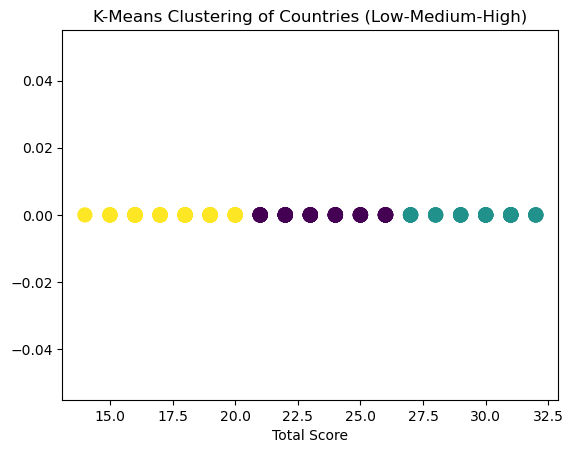

In [118]:
plt.scatter(df['total_score'], [0] * len(df), c=df['Cluster'], cmap='viridis', s=100)
plt.xlabel("Total Score")
plt.title("K-Means Clustering of Countries (Low-Medium-High)")
plt.show()